In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
V=np.array([0.40,0.50,0.60])
I=np.array([1.22e-6,5.38e-5,2.44e-3])
lnI=np.log(I)
slope,intercept=np.polyfit(V,lnI,1)
i0=np.exp(intercept)
print(f"extracted saturation current: {i0:.2e}A")

extracted saturation current: 3.04e-13A


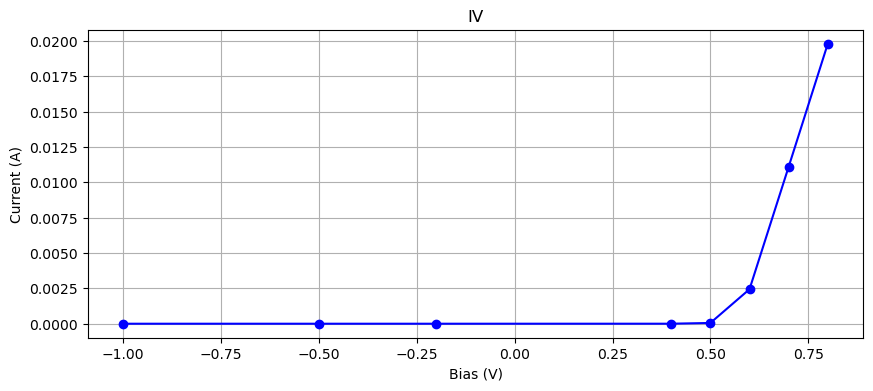

In [19]:
V=np.array([-1.00,-0.5,-0.2,0.40,0.50,0.60,0.70,0.80])
I=np.array([-2.06e-13,-1.99e-13,-1.84e-13,1.22e-6,5.38e-5,2.44e-3,1.11e-2,1.98e-2])
plt.figure(figsize=(10, 4))
plt.plot(V,I,'bo-')
plt.xlabel('Bias (V)')
plt.ylabel('Current (A)')
plt.title('IV')
plt.grid(True)

Extracted I0: 3.0358e-13 A


In [24]:
t=np.array([0,10,20,30,40,50])
dn=np.array([1.0e15,6.1e14,3.7e14,2.3e14,1.4e14,8.7e13])
lndn=np.log(dn)
slope,intercept=np.polyfit(t,lndn,1)
tau=-1/slope
print(f"effective lifetime: {tau:.4f} us")

effective lifetime: 20.4677 us


## Ex2

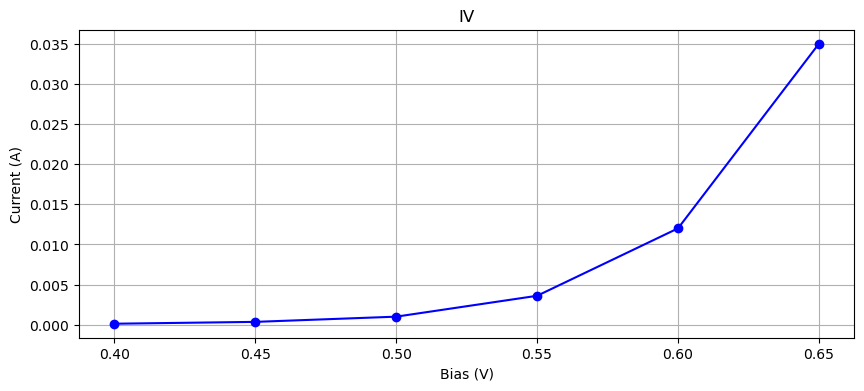

In [16]:
V=np.array([0.40,0.45,0.50,0.55,0.60,0.65])
I=np.array([0.12,0.35,1.00,3.60,12.00,35.00])/1000
plt.figure(figsize=(10, 4))
plt.plot(V,I,'bo-')
plt.xlabel('Bias (V)')
plt.ylabel('Current (A)')
plt.title('IV')
plt.grid(True)

In [21]:
lnI=np.log(I)
slope,intercept=np.polyfit(V,lnI,1)
i0=np.exp(intercept)
print(f"extracted saturation current: {i0:.2e}A")

extracted saturation current: 1.13e-08A


In [18]:
print(slope)

23.007530375296923


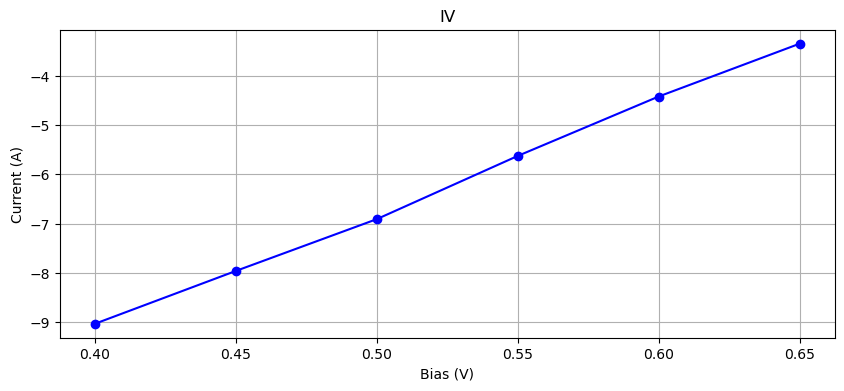

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(V,lnI,'bo-')
plt.xlabel('Bias (V)')
plt.ylabel('Current (A)')
plt.title('IV')
plt.grid(True)

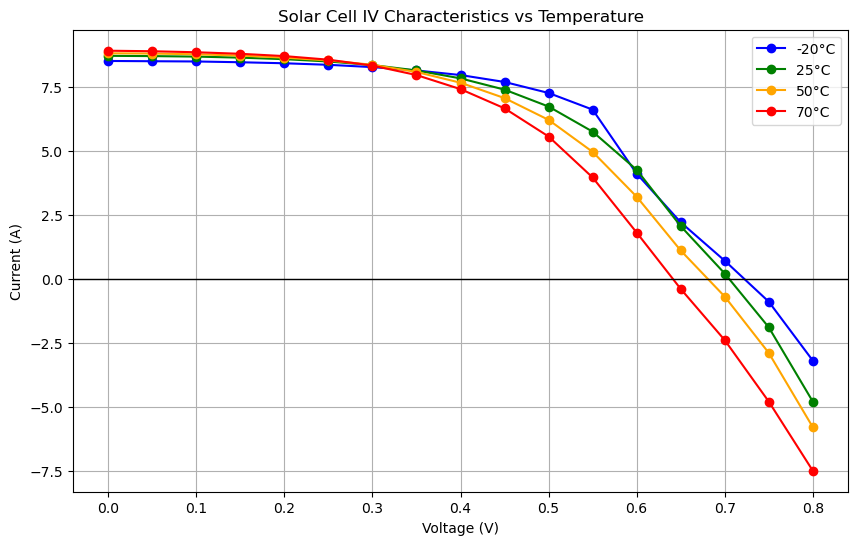

Temperature Coefficients:
dV_OC/dT: -0.900 mV/°C
dI_SC/dT: 4.444 mA/°C
d_eta/dT: -0.029 %/°C


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Definition ---
# Voltage values from the table
V = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8])

# Temperature data arrays (Current I in Amperes)
temps = np.array([-20, 25, 50, 70])
I_data = {
    -20: np.array([8.50, 8.49, 8.48, 8.45, 8.41, 8.35, 8.26, 8.13, 7.95, 7.68, 7.25, 6.60, 4.10, 2.20, 0.70, -0.90, -3.20]),
    25:  np.array([8.70, 8.69, 8.67, 8.63, 8.57, 8.48, 8.34, 8.13, 7.82, 7.38, 6.72, 5.74, 4.25, 2.05, 0.20, -1.90, -4.80]),
    50:  np.array([8.80, 8.79, 8.76, 8.71, 8.63, 8.52, 8.35, 8.07, 7.65, 7.05, 6.20, 4.95, 3.20, 1.10, -0.70, -2.90, -5.80]),
    70:  np.array([8.90, 8.88, 8.84, 8.78, 8.69, 8.55, 8.32, 7.95, 7.40, 6.65, 5.55, 3.95, 1.80, -0.40, -2.40, -4.80, -7.50])
}

area = 156 * 156 / 100 # 243.36 cm2
P_in = 0.1 * area      # 24.336 Watts (assuming 100 mW/cm2)

results = {}

# --- Plotting ---
plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'orange', 'red']

for i, T in enumerate(temps):
    I = I_data[T]
    plt.plot(V, I, label=f'{T}°C', color=colors[i], marker='o')
    
    # Calculate performance metrics
    isc = I[0]
    # Use interpolation to find Voc (where I=0)
    voc = np.interp(0, I[::-1], V[::-1])
    # P = V * I
    P = V * I
    p_max = np.max(P)
    eff = (p_max / P_in) * 100
    results[T] = {'ISC': isc, 'VOC': voc, 'EFF': eff, 'PMAX': p_max}

plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.title('Solar Cell IV Characteristics vs Temperature')
plt.legend()
plt.grid(True)
plt.show()

# --- Finite Difference Calculation ---
# Coefficient = (Val_high - Val_low) / (T_high - T_low)
dT = 70 - (-20)
dVoc_dT = (results[70]['VOC'] - results[-20]['VOC']) / dT
dIsc_dT = (results[70]['ISC'] - results[-20]['ISC']) / dT
dEff_dT = (results[70]['EFF'] - results[-20]['EFF']) / dT

print(f"Temperature Coefficients:")
print(f"dV_OC/dT: {dVoc_dT*1000:.3f} mV/°C")
print(f"dI_SC/dT: {dIsc_dT*1000:.3f} mA/°C")
print(f"d_eta/dT: {dEff_dT:.3f} %/°C")

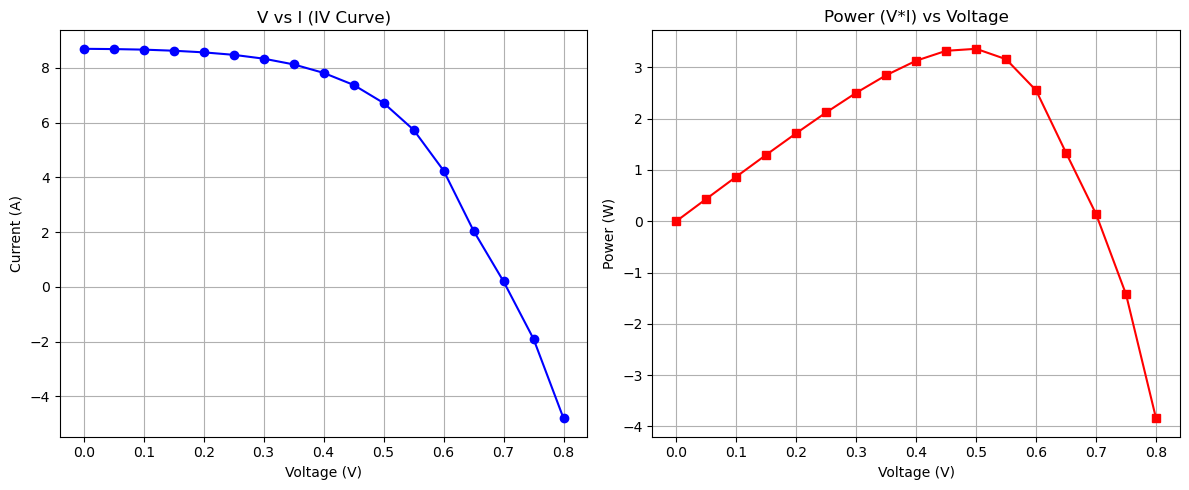

In [2]:

# Data transcribed from the provided table
v_values = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
i_values = [8.70, 8.69, 8.67, 8.63, 8.57, 8.48, 8.34, 8.13, 7.82, 7.38, 6.72, 5.74, 4.25, 2.05, 0.20, -1.90, -4.80]

# Calculate Power (P = V * I)
p_values = [v * i for v, i in zip(v_values, i_values)]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: V vs I
ax1.plot(v_values, i_values, marker='o', color='blue', linestyle='-')
ax1.set_title('V vs I (IV Curve)')
ax1.set_xlabel('Voltage (V)')
ax1.set_ylabel('Current (A)')
ax1.grid(True)

# Plot 2: V * I vs V (Power Curve)
ax2.plot(v_values, p_values, marker='s', color='red', linestyle='-')
ax2.set_title('Power (V*I) vs Voltage')
ax2.set_xlabel('Voltage (V)')
ax2.set_ylabel('Power (W)')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [3]:
"""
V = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8])

# Temperature data arrays (Current I in Amperes)
temps = np.array([-20, 25, 50, 70])
I_data = {
    -20: np.array([8.50, 8.49, 8.48, 8.45, 8.41, 8.35, 8.26, 8.13, 7.95, 7.68, 7.25, 6.60, 4.10, 2.20, 0.70, -0.90, -3.20]),
    25:  np.array([8.70, 8.69, 8.67, 8.63, 8.57, 8.48, 8.34, 8.13, 7.82, 7.38, 6.72, 5.74, 4.25, 2.05, 0.20, -1.90, -4.80]),
    50:  np.array([8.80, 8.79, 8.76, 8.71, 8.63, 8.52, 8.35, 8.07, 7.65, 7.05, 6.20, 4.95, 3.20, 1.10, -0.70, -2.90, -5.80]),
    70:  np.array([8.90, 8.88, 8.84, 8.78, 8.69, 8.55, 8.32, 7.95, 7.40, 6.65, 5.55, 3.95, 1.80, -0.40, -2.40, -4.80, -7.50])
}
"""

'\nV = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8])\n\n# Temperature data arrays (Current I in Amperes)\ntemps = np.array([-20, 25, 50, 70])\nI_data = {\n    -20: np.array([8.50, 8.49, 8.48, 8.45, 8.41, 8.35, 8.26, 8.13, 7.95, 7.68, 7.25, 6.60, 4.10, 2.20, 0.70, -0.90, -3.20]),\n    25:  np.array([8.70, 8.69, 8.67, 8.63, 8.57, 8.48, 8.34, 8.13, 7.82, 7.38, 6.72, 5.74, 4.25, 2.05, 0.20, -1.90, -4.80]),\n    50:  np.array([8.80, 8.79, 8.76, 8.71, 8.63, 8.52, 8.35, 8.07, 7.65, 7.05, 6.20, 4.95, 3.20, 1.10, -0.70, -2.90, -5.80]),\n    70:  np.array([8.90, 8.88, 8.84, 8.78, 8.69, 8.55, 8.32, 7.95, 7.40, 6.65, 5.55, 3.95, 1.80, -0.40, -2.40, -4.80, -7.50])\n}\n'

In [6]:
V = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8])
Im20 = np.array([8.50, 8.49, 8.48, 8.45, 8.41, 8.35, 8.26, 8.13, 7.95, 7.68, 7.25, 6.60, 4.10, 2.20, 0.70, -0.90, -3.20])
I25 = np.array([8.70, 8.69, 8.67, 8.63, 8.57, 8.48, 8.34, 8.13, 7.82, 7.38, 6.72, 5.74, 4.25, 2.05, 0.20, -1.90, -4.80])
I50 = np.array([8.80, 8.79, 8.76, 8.71, 8.63, 8.52, 8.35, 8.07, 7.65, 7.05, 6.20, 4.95, 3.20, 1.10, -0.70, -2.90, -5.80])
I70 =  np.array([8.90, 8.88, 8.84, 8.78, 8.69, 8.55, 8.32, 7.95, 7.40, 6.65, 5.55, 3.95, 1.80, -0.40, -2.40, -4.80, -7.50])
p_valuesm20 = [v * i for v, i in zip(V, Im20)]
p_values25 = [v * i for v, i in zip(V, I25)]
p_values50 = [v * i for v, i in zip(V, I50)]
p_values70 = [v * i for v, i in zip(V, I70)]

In [14]:
print(np.max(p_valuesm20),'W')
print(np.max(p_values25),'W')
print(np.max(p_values50),'W')
print(np.max(p_values70),'W')

3.63 W
3.36 W
3.1725 W
2.9925 W


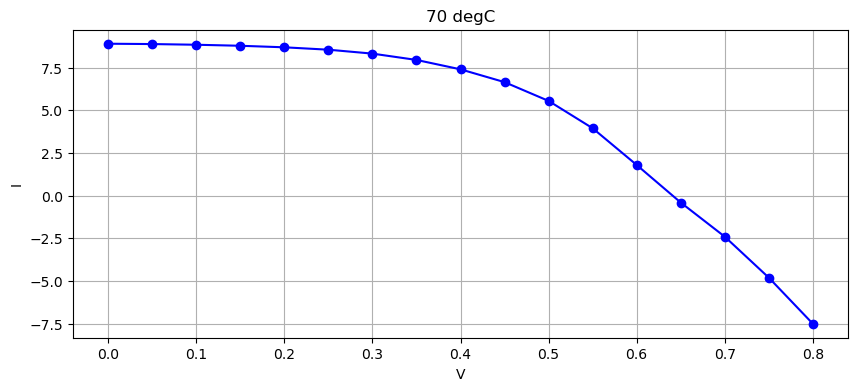

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(V,I70,'bo-')
plt.xlabel('V')
plt.ylabel('I')
plt.title('70 degC')
plt.grid(True)

In [26]:
pm20 = np.max(p_valuesm20)
p25 = np.max(p_values25)


[0.0,
 0.44400000000000006,
 0.884,
 1.317,
 1.738,
 2.1375,
 2.496,
 2.7824999999999998,
 2.9600000000000004,
 2.9925,
 2.775,
 2.1725000000000003,
 1.08,
 -0.26,
 -1.68,
 -3.5999999999999996,
 -6.0]

## Exercise 3

In [14]:
W = 80
distances = np.array([30, 40, 50, 70, 80]) 
wafer_data = {
    'Wafer 1': np.array([26.8, 33.7, 42.3, 56.0, 65.0]),
    'Wafer 2': np.array([31.5, 38.6, 46.9, 61.8, 71.2]),
    'Wafer 3': np.array([18.3, 22.9, 29.1, 38.8, 44.1])
}
print(f"{'Wafer':<10} | {'Rs (Ω/sq)':<12} | {'Rc (Ω)':<10} | {'Lt (µm)':<10} | {'ρc (Ω·cm²)':<12}")
print("-" * 65)
for name, resistances in wafer_data.items():
    slope, yintercept = np.polyfit(distances, resistances, 1)    
    rs = slope * W    
    rc = yintercept / 2
    x_intercept = -yintercept / slope
    lt = abs(x_intercept) / 2
    rho_c = rs * (lt * 1e-4)**2
    print(f"{name:<10} | {rs:<12.4f} | {rc:<10.4f} | {lt:<10.4f} | {rho_c:<12.4e}")


Wafer      | Rs (Ω/sq)    | Rc (Ω)     | Lt (µm)    | ρc (Ω·cm²)  
-----------------------------------------------------------------
Wafer 1    | 60.5488      | 1.9448     | 2.5695     | 3.9977e-06  
Wafer 2    | 63.0698      | 3.7140     | 4.7109     | 1.3997e-05  
Wafer 3    | 41.4512      | 1.3302     | 2.5673     | 2.7321e-06  


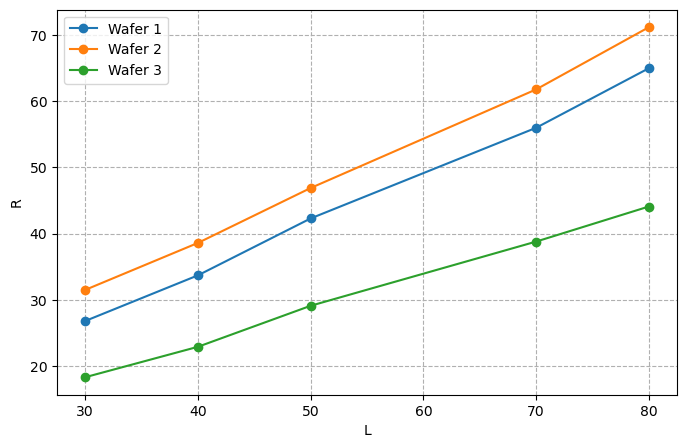

In [15]:
plt.figure(figsize=(8, 5))

# Plotting each wafer with a unique color and marker
for name, R in wafer_data.items():
    plt.plot(distances, R, marker='o', linestyle='-', label=name)

plt.xlabel('L')
plt.ylabel('R')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

## Exercise 4

Extracted Cox: 6.91e-07 F/cm²
Extracted Vfb: 0.84 V
Extracted Vt: 0.22 V


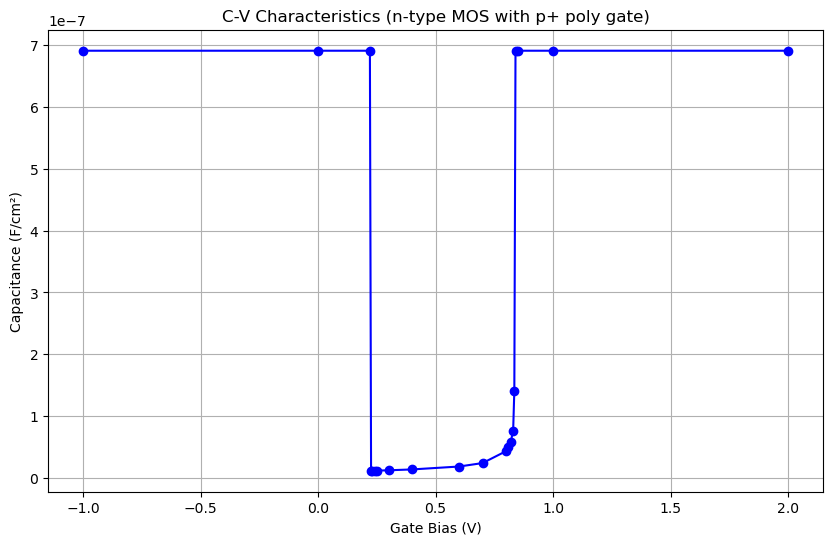

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Bias and Capacitance data
bias = np.array([2, 1, 0.85, 0.84, 0.835, 0.83, 0.82, 0.81, 0.8, 0.7, 0.6, 0.4, 0.3, 0.25, 0.24, 0.23, 0.225, 0.22, 0, -1])
capacitance = np.array([6.91e-7, 6.91e-7, 6.91e-7, 6.91e-7, 1.41e-7, 7.65e-8, 5.86e-8, 4.93e-8, 4.33e-8, 2.40e-8, 1.84e-8, 1.37e-8, 1.23e-8, 1.18e-8, 1.18e-8, 1.16e-8, 1.16e-8, 6.91e-7, 6.91e-7, 6.91e-7])

# Plotting the C-V curve
plt.figure(figsize=(10, 6))
plt.plot(bias, capacitance, 'bo-', label='Measured C-V Data')
plt.xlabel('Bias)')
plt.ylabel('Capacitance')
plt.title('C-V characteristics')
plt.grid(True)
#plt.savefig('cv_plot.png')

# Extracting values from the data
cox = np.max(capacitance)
v_fb = 0.84  # Point where C starts dropping below Cox
v_t = 0.22   # Point where C jumps back to Cox

print(f"Extracted Cox: {cox} F/cm²")
print(f"Extracted Vfb: {v_fb} V")
print(f"Extracted Vt: {v_t} V")

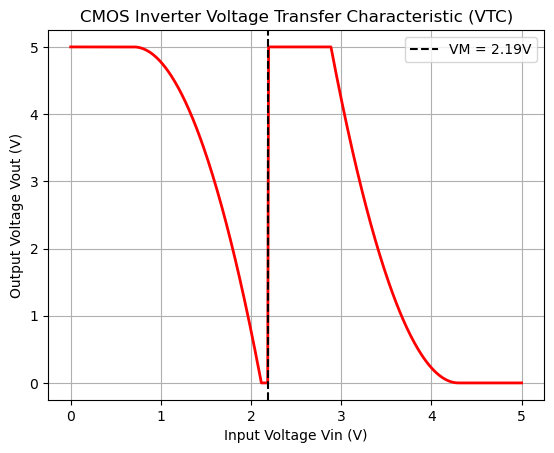

In [3]:


# Device Parameters
Vdd = 5.0
Vtn = 0.7
Vtp = -0.7
Vin = np.linspace(0, 5, 500)
Vout = []

for v_in in Vin:
    if v_in < Vtn: # Region A
        v_out = Vdd
    elif v_in > (Vdd + Vtp): # Region E
        v_out = 0
    else:
        # In transition (approximate linear/sat balance)
        # Using VM calculation to mid-point the curve
        if v_in < 2.19:
            v_out = Vdd - 2.5 * (v_in - Vtn)**2 # Heuristic for plot
        else:
            v_out = 2.5 * (Vdd + Vtp - v_in)**2 # Heuristic for plot
    Vout.append(np.clip(v_out, 0, Vdd))

plt.plot(Vin, Vout, 'r', lw=2)
plt.axvline(x=2.19, color='k', linestyle='--', label='VM = 2.19V')
plt.xlabel('Input Voltage Vin (V)')
plt.ylabel('Output Voltage Vout (V)')
plt.title('CMOS Inverter Voltage Transfer Characteristic (VTC)')
plt.grid(True)
plt.legend()
plt.show()

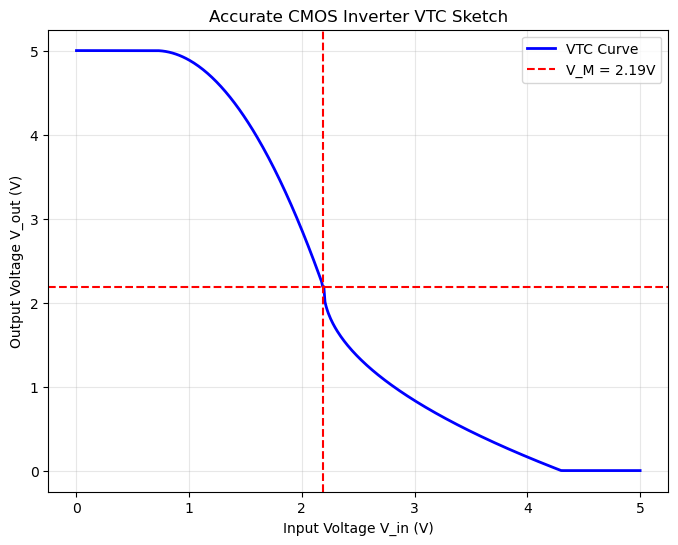

In [4]:

# Parameters from Task 6
Vdd = 5.0
Vtn = 0.7
Vtp = -0.7  # |Vtp| = 0.7
kn = 100e-6 # un*Cox*W/L
kp = 50e-6  # up*Cox*W/L

Vin = np.linspace(0, 5, 500)
Vout = []

for vi in Vin:
    # Region A: NMOS Cutoff
    if vi <= Vtn:
        vo = Vdd
    # Region E: PMOS Cutoff
    elif vi >= (Vdd + Vtp):
        vo = 0
    # Region C: Both Saturation (Transition point)
    elif abs(vi - 2.19) < 0.01:
        vo = 2.19
    # Region B & D: Solving for current balance (Simplified for plotting)
    else:
        # For a sketch, we interpolate between Vdd, VM, and 0
        if vi < 2.19:
            # Transition from Vdd to VM
            vo = Vdd - (Vdd - 2.19) * ((vi - Vtn) / (2.19 - Vtn))**2
        else:
            # Transition from VM to 0
            vo = 2.19 * (1 - ((vi - 2.19) / (Vdd + Vtp - 2.19))**0.5)
    Vout.append(vo)

plt.figure(figsize=(8, 6))
plt.plot(Vin, Vout, 'b-', linewidth=2, label="VTC Curve")
plt.axvline(x=2.19, color='r', linestyle='--', label='V_M = 2.19V')
plt.axhline(y=2.19, color='r', linestyle='--')
plt.title("Accurate CMOS Inverter VTC Sketch")
plt.xlabel("Input Voltage V_in (V)")
plt.ylabel("Output Voltage V_out (V)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()